In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pycontrails import Fleet

In [2]:
dff = pd.read_parquet("../data/filed/filed_trajectories_EAGWP100.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/optimised/optimised_trajectories_EAGWP100.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [3]:
from cane.utils import mask_by_marker

mask_by_marker(fleetf, ["nox", "NOx", "O3", "CH4"])
mask_by_marker(fleeto, ["nox", "NOx", "O3", "CH4"])

dff = fleetf.dataframe
dfo = fleeto.dataframe

Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4


In [4]:
from cane.utils import mask_by_validity_range

bounds = [150, 350]
mask_by_validity_range(fleetf, ["nox", "NOx", "O3", "CH4"], bounds)
mask_by_validity_range(fleeto, ["nox", "NOx", "O3", "CH4"], bounds)

dff = fleetf.dataframe
dfo = fleeto.dataframe

Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4


In [5]:
from cane.utils import df_diff

# create aggregates (total)
org_sum = (
    dff[["flight_id", "fuel_burn", "nox", "NOx"]]
    .groupby(["flight_id"]).sum().reset_index()
)
opt_sum = (
    dfo[["flight_id", "fuel_burn", "nox", "NOx"]]
    .groupby(["flight_id"]).sum().reset_index()
)
my_diff = df_diff(org_sum, opt_sum, on=["flight_id"], keep_originals=True)
my_diff = pd.merge(
    my_diff,
    dff.groupby("flight_id").day.first(),
    on="flight_id",
)

In [6]:
# my_diff = my_diff.query("nox_optimised != 0").reset_index(drop=True)
# print(my_diff.shape[0], "flights")

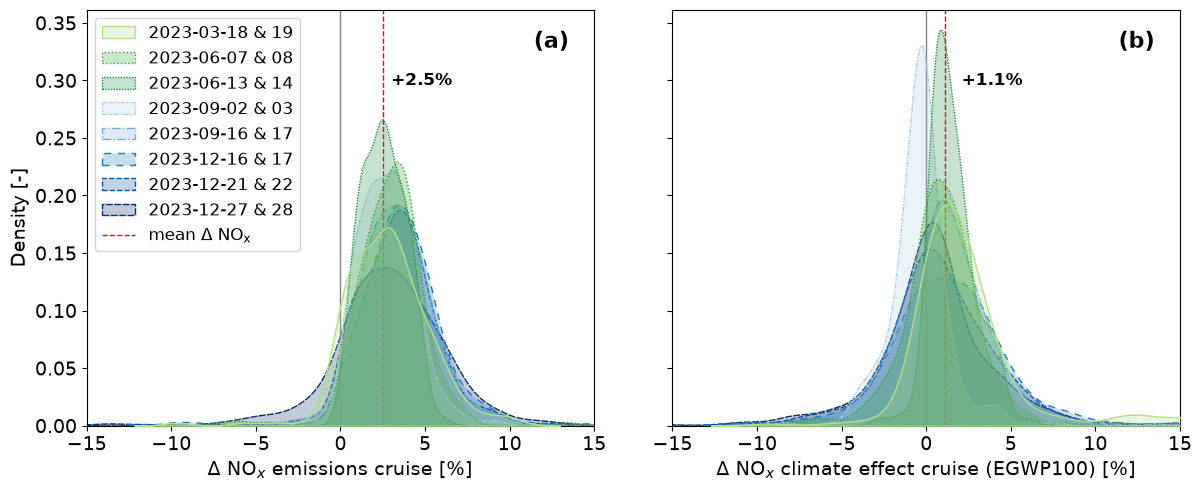

In [7]:
# columns: day, nox_reldiff, co2eq_nox_reldiff
from cane.labels import friendly_days


def plot_two_kdes(g, friendly_days, save_path=None):
    """
    Makes a two-panel KDE plot of:
      (a) NOx relative difference
      (b) CO2eq-NOx relative difference
    Each panel has KDEs grouped by 'day' with fill.
    """

    colors = [
        # Group 1 — light green (#b2df8a), only one
        "#b2df8a",
        # Group 2 — dark green (#33a02c)
        "#33a02c", "#238b45",
        # Group 3 — light blue (#a6cee3)
        "#a6cee3", "#74add1",  # much lighter + medium blue
        # Group 4 — dark blue (#1f78b4)
        "#1f78b4", "#08519c", "#08306b"  # progressively darker navy tones
    ]

    linestyles = ["-",
                  ":", (0, (1, 1)),
                  (0, (3, 1, 1, 1, 1, 1)), "-.",
                  (0, (5, 5)), "--", (0, (5, 1))]

    days = sorted(g["day"].unique())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    plt.subplots_adjust(wspace=4)

    # --------------------------------
    # Helper to avoid duplication
    # --------------------------------
    def plot_panel(ax, xvar, title=None):
        for color, style, day in zip(colors, linestyles, days):
            sns.kdeplot(
                data=g.query("day == @day"),
                x=g.query("day == @day")[xvar] * 100,
                label=friendly_days[day - 1],
                color=color,
                linestyle=style,
                fill=True,
                zorder=8 - day,
                ax=ax
            )

        ax.axvline(0, color="gray", linestyle="solid", linewidth=1)
        ax.set_xlim([-15, 15])
        ax.set_xlabel(title, fontsize=14)
        ax.set_ylabel("Density [-]", fontsize=14)
        ax.tick_params(axis="x", labelsize=14)
        ax.tick_params(axis="y", labelsize=14)
        ax.grid(False)

    # --------------------------------
    # Plot both panels
    # --------------------------------
    plot_panel(axes[0], "nox_reldiff", "$\Delta$ NO$_x$ emissions cruise [%]")
    plot_panel(axes[1], "NOx_reldiff", "$\Delta$ NO$_x$ climate effect cruise (EGWP100) [%]")

    mean_nox = g["nox_diff"].sum() / g["nox_filed"].sum() * 100
    mean_NOx = g["NOx_diff"].sum() / g["NOx_filed"].sum() * 100
    axes[0].axvline(mean_nox, color="red", linestyle="--", linewidth=1, label=r"mean $\Delta$ NO$\rm_x$")
    axes[1].axvline(mean_NOx, color="red", linestyle="--", linewidth=1, label=r"mean $\Delta$ NO$\rm_x$")
    axes[0].text(
        0.72, 0.85, f"+{mean_nox:.1f}%",
        transform=axes[0].transAxes,
        fontsize=12, fontweight="bold",
        va="top", ha="right"
    )
    axes[1].text(
        0.69, 0.85, f"+{mean_NOx:.1f}%",
        transform=axes[1].transAxes,
        fontsize=12, fontweight="bold",
        va="top", ha="right"
    )

    # --------------------------------
    # Add subplot labels
    # --------------------------------
    axes[0].text(
        0.95, 0.95, "(a)",
        transform=axes[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="right"
    )

    axes[1].text(
        0.95, 0.95, "(b)",
        transform=axes[1].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="right"
    )

    # Put legend only on panel (a)
    axes[0].legend(loc="upper left", fontsize=12)
    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()


plot_two_kdes(my_diff, friendly_days, f"../figures/fig03.png")

In [8]:
print(my_diff.query("nox_diff > 0").shape[0] / my_diff.shape[0] * 100)
print(my_diff.query("NOx_diff > 0").shape[0] / my_diff.shape[0] * 100)

93.11770428015565
65.0535019455253
